In [1]:
pip install boto3           

You should consider upgrading via the '/Users/anirudhiyer/Desktop/AWS Full Pipeline/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import boto3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### Load Data From Amazon S3

In [ ]:
import boto3
import pandas as pd

bucket = "customer-satisfaction-with-deploy"
key = "data/train_final.csv"

s3 = boto3.client("s3")

obj = s3.get_object(
    Bucket=bucket,
    Key=key
)

df_train = pd.read_csv(obj["Body"])

In [5]:
bucket = "customer-satisfaction-with-deploy"
key = "data/test.csv"

s3 = boto3.client("s3")

obj = s3.get_object(
    Bucket=bucket,
    Key=key
)

df_test = pd.read_csv(obj["Body"])

In [6]:
df_train.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1.0,0.0,13,1.0,2.0,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0.0
1,1.0,1.0,25,0.0,0.0,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0.0
2,0.0,0.0,26,0.0,0.0,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1.0
3,0.0,0.0,25,0.0,0.0,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0.0
4,1.0,0.0,61,0.0,0.0,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1.0


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             103904 non-null  float64
 1   Customer Type                      103904 non-null  float64
 2   Age                                103904 non-null  int64  
 3   Type of Travel                     103904 non-null  float64
 4   Class                              103904 non-null  float64
 5   Flight Distance                    103904 non-null  int64  
 6   Inflight wifi service              103904 non-null  int64  
 7   Departure/Arrival time convenient  103904 non-null  int64  
 8   Ease of Online booking             103904 non-null  int64  
 9   Gate location                      103904 non-null  int64  
 10  Food and drink                     103904 non-null  int64  
 11  Online boarding                    1039

### Data Preprocessing already done through AWS Canvas -> AWS Data Wrangler 

### Feature Distribution

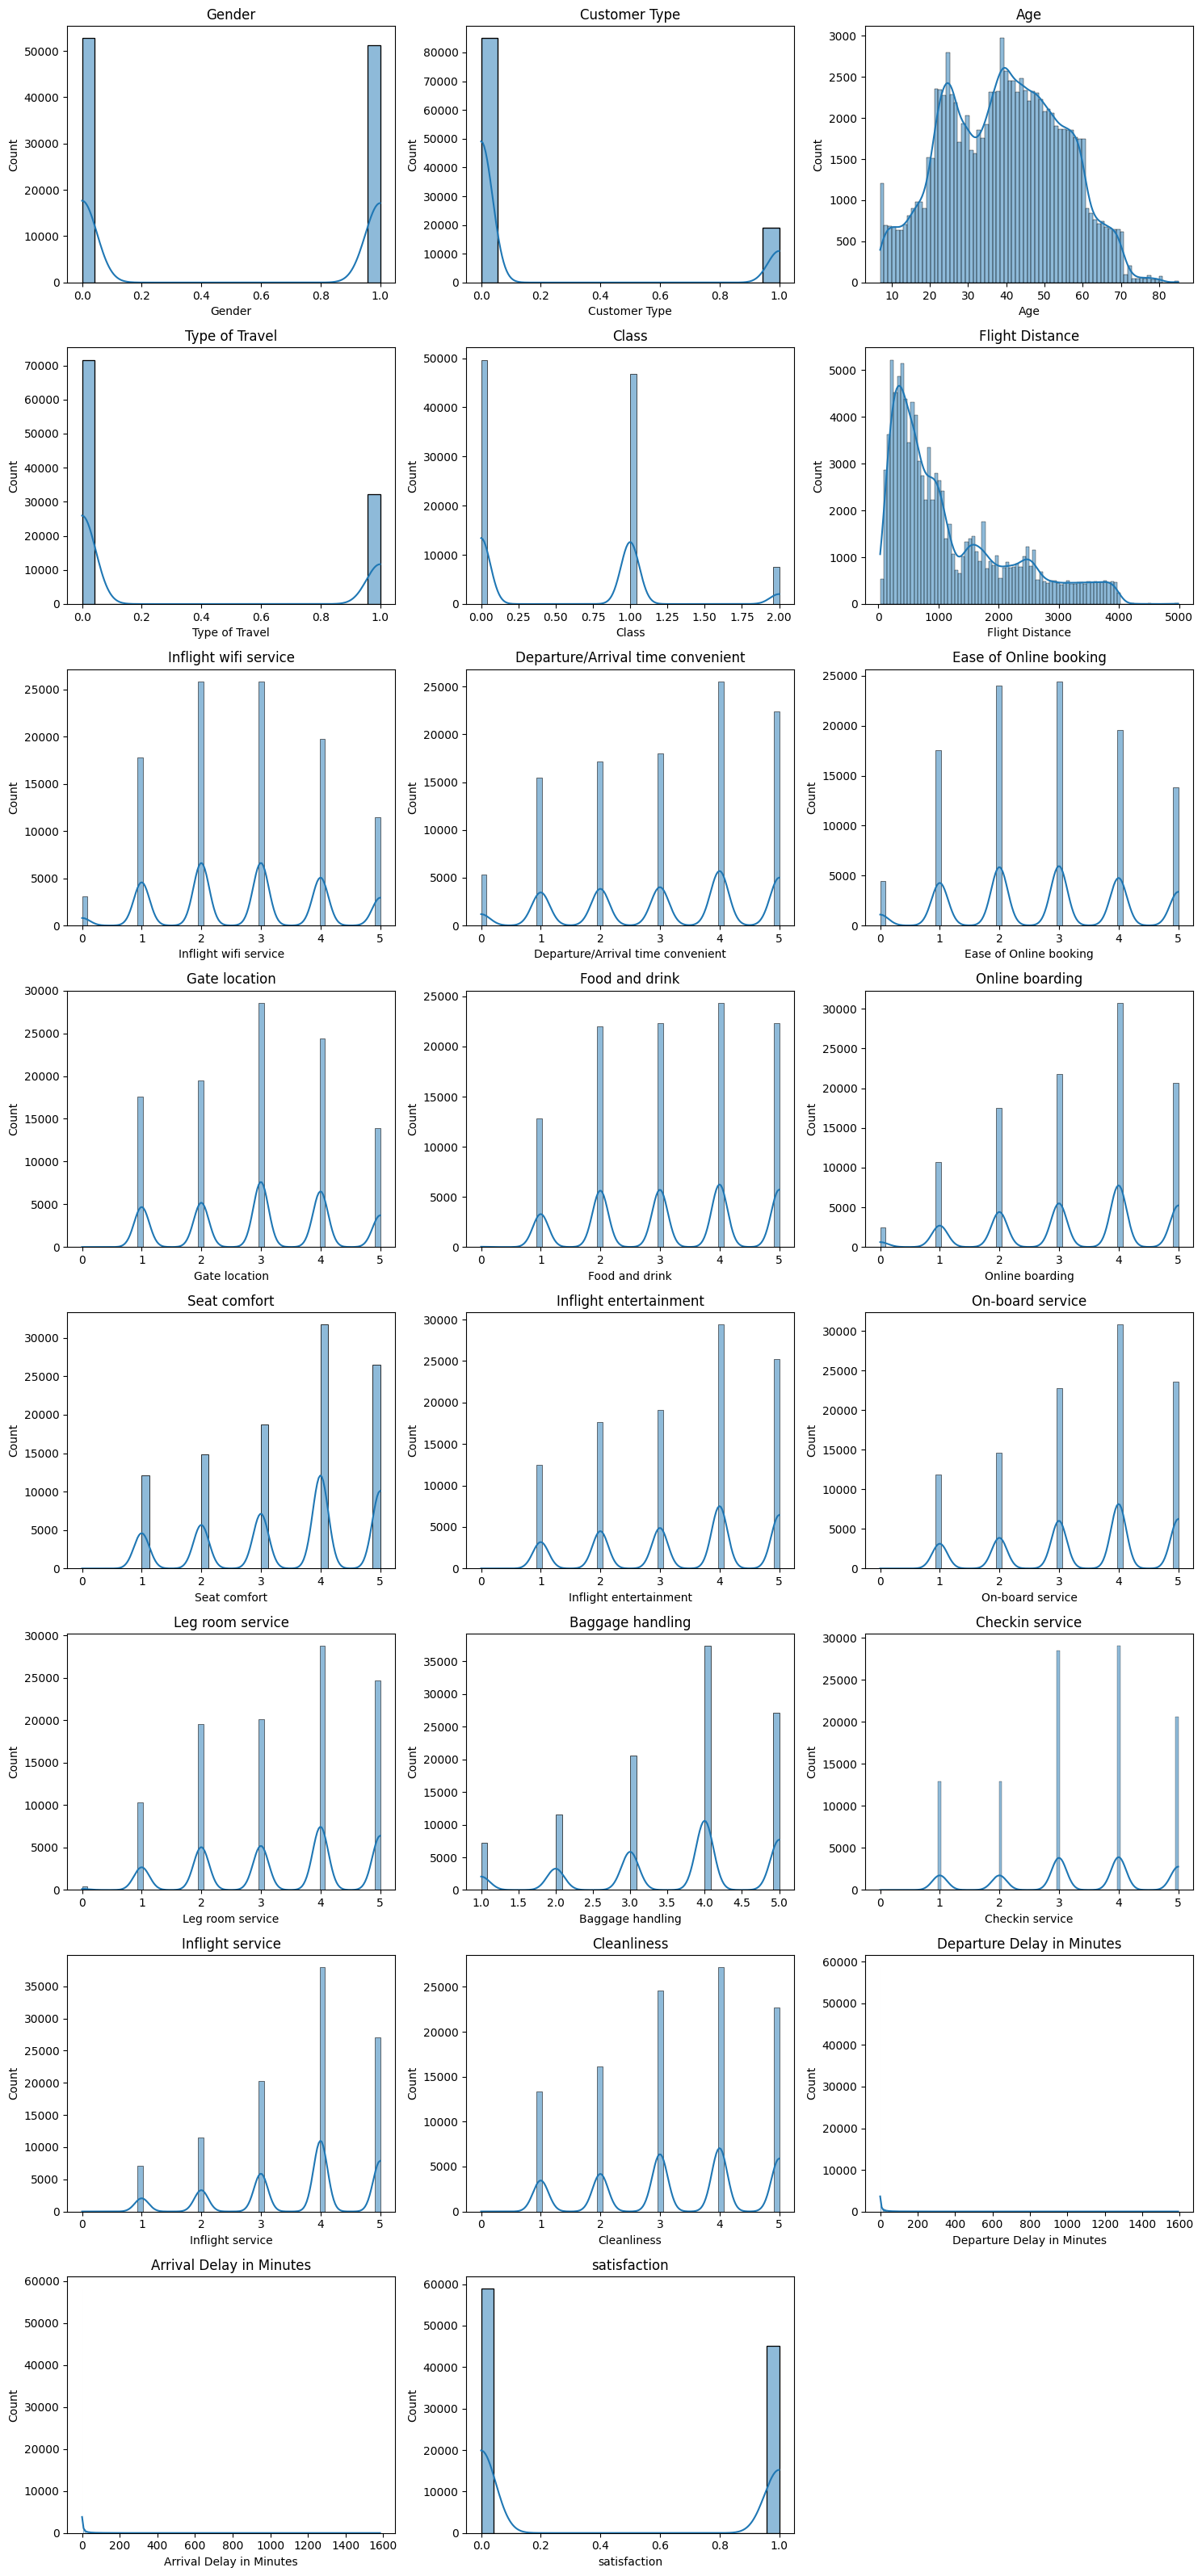

In [8]:
## Basic EDA For the Notebook

num_cols=df_train.select_dtypes(include=np.number).columns
ncols=3
nrows=int(np.ceil(len(num_cols)/ncols))
fig,axes=plt.subplots(nrows,ncols,figsize=(15,nrows*4))
axes=axes.flatten()

for i,col in enumerate(num_cols):
    sns.histplot(x=df_train[col],kde=True,ax=axes[i])
    axes[i].set_title(col)

for j in range(i+1,len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Correlation Analaysis

<Axes: >

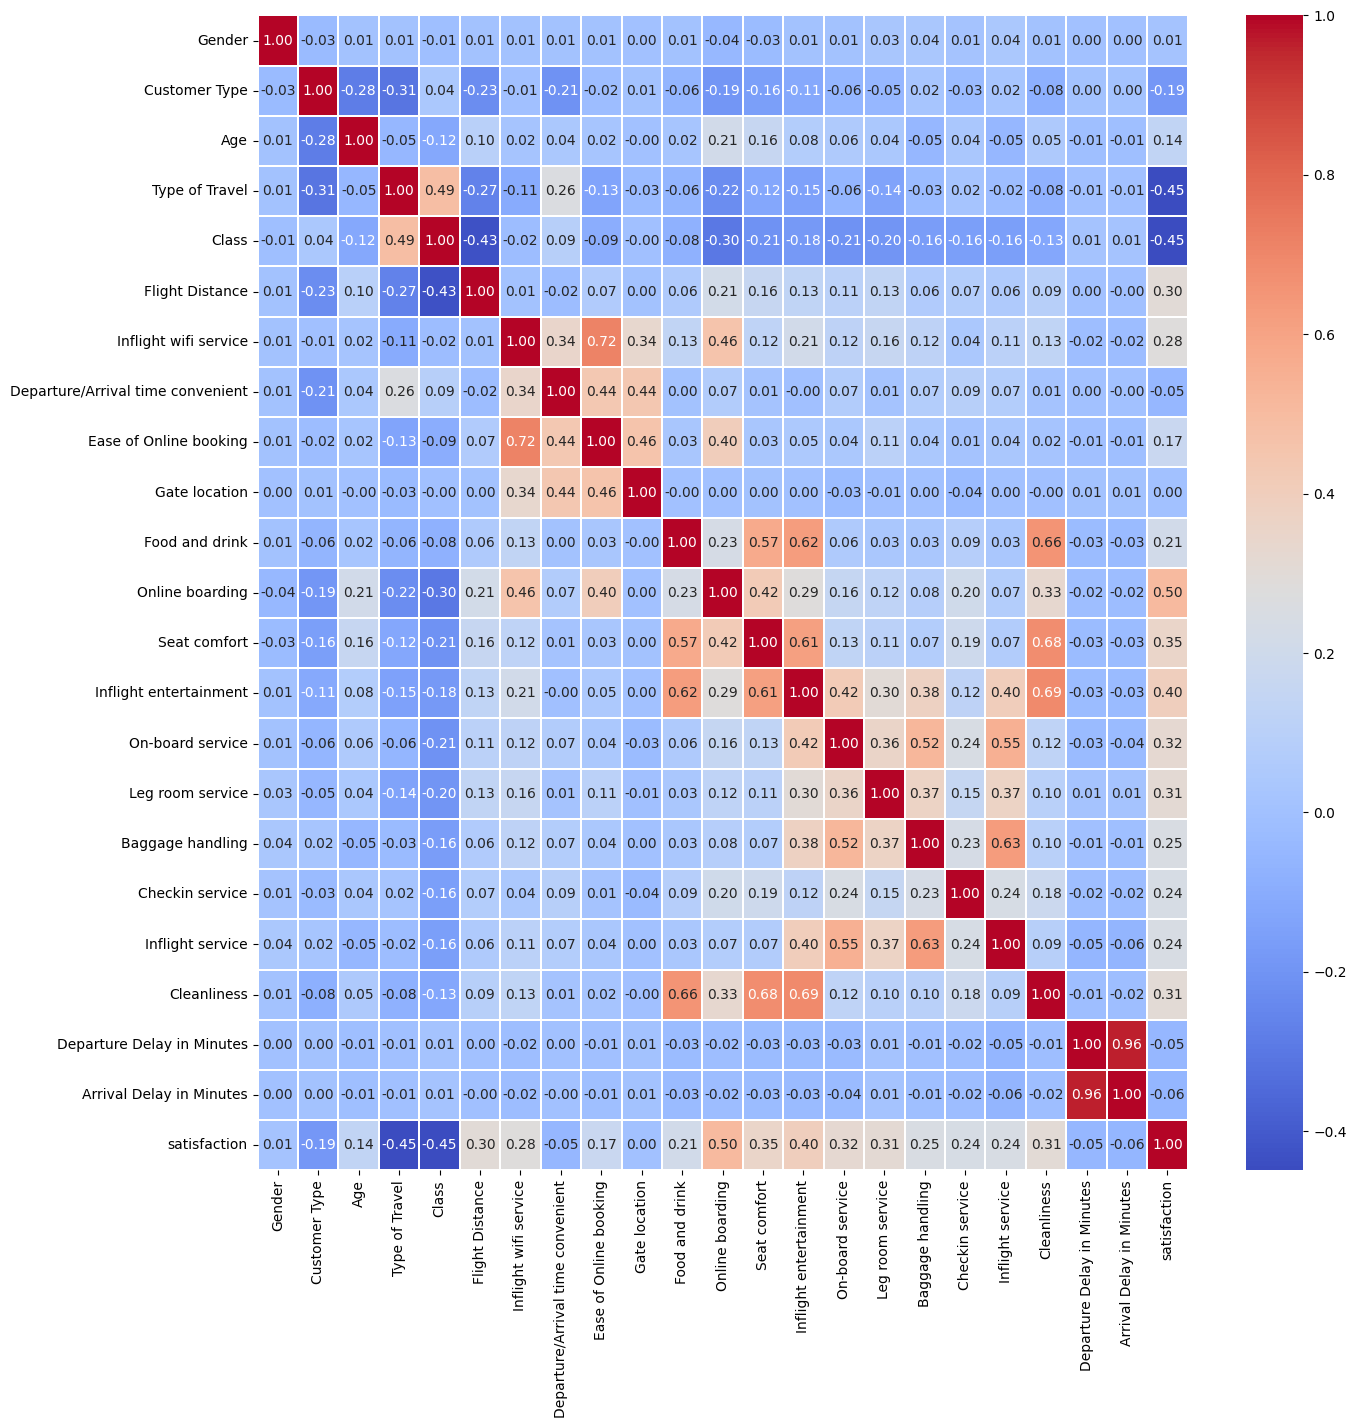

In [9]:
corr=df_train.corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr,annot=True,fmt='.2f',linewidths=0.1,cmap='coolwarm')

<Axes: xlabel='Type of Travel', ylabel='count'>

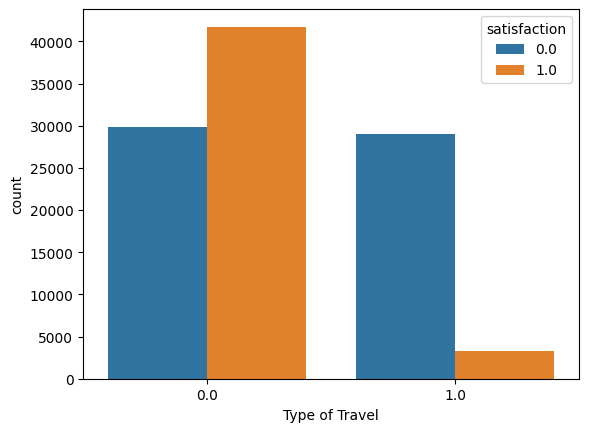

In [10]:
sns.countplot(x='Type of Travel',hue='satisfaction',data=df_train)

### Business Travellers are more satisified then Personal Travellers

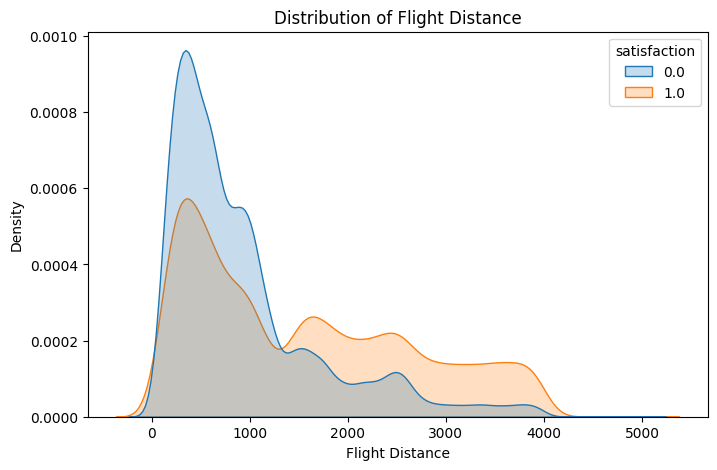

In [11]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_train,
    x='Flight Distance',
    hue='satisfaction',
    fill=True,
    common_norm=False
)

plt.title("Distribution of Flight Distance")
plt.show()

### Longer the flight Distance more satisied are customers

(0.0, 50.0)

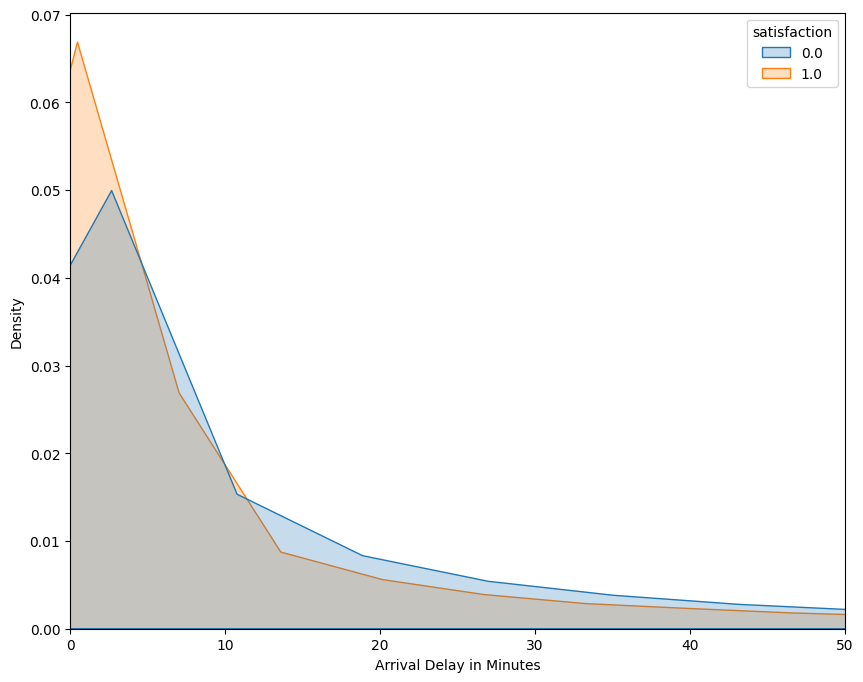

In [12]:
plt.figure(figsize=(10,8))
sns.kdeplot(data=df_train,x='Arrival Delay in Minutes',hue='satisfaction',common_norm=False,fill=True)
plt.xlim(0,50)

### Lower Arrival Delay , More Satisfied Customers

### Apply Encoding to Test Data before Model Training

In [13]:
df_test.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [14]:
df_test.drop(columns=['Unnamed: 0','id'],inplace=True)

In [15]:
df_test['Gender']=df_test['Gender'].map({'Female':1,'Male':0})

In [16]:
df_test.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,0,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,0,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,1,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [17]:
df_test['satisfaction']=df_test['satisfaction'].map({'satisfied':1,'neutral or dissatisfied':0})

In [18]:
df_test.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,1
1,1,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,1
2,0,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,0
3,0,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,1
4,1,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,1


In [19]:
df_test['Type of Travel']=df_test['Type of Travel'].map({'Business travel':0,'Personal Travel':1})

In [20]:
df_test.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,Loyal Customer,52,0,Eco,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,1
1,1,Loyal Customer,36,0,Business,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,1
2,0,disloyal Customer,20,0,Eco,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,0
3,0,Loyal Customer,44,0,Business,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,1
4,1,Loyal Customer,49,0,Eco,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,1


In [21]:
df_test['Customer Type']=df_test['Customer Type'].map({'Loyal Customer':0,'disloyal Customer':1})

In [22]:
df_test.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,0,52,0,Eco,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,1
1,1,0,36,0,Business,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,1
2,0,1,20,0,Eco,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,0
3,0,0,44,0,Business,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,1
4,1,0,49,0,Eco,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,1


In [23]:
df_test['Class']=df_test['Class'].map({'Business':0,'Eco':1,'Eco Plus':2})

In [24]:
df_test.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,0,52,0,1,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,1
1,1,0,36,0,0,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,1
2,0,1,20,0,1,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,0
3,0,0,44,0,0,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,1
4,1,0,49,0,1,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,1


### Model Training

In [25]:
X_train=df_train.drop('satisfaction',axis=1)
y_train=df_train['satisfaction']
X_test=df_test.drop('satisfaction',axis=1)
y_test=df_test['satisfaction']

In [26]:
X_train.shape

(103904, 22)

In [27]:
X_test.shape

(25976, 22)

### XgBoost Model

In [28]:
pip install xgboost

You should consider upgrading via the '/Users/anirudhiyer/Desktop/AWS Full Pipeline/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [29]:
import xgboost as xgb
model=xgb.XGBClassifier(n_estimators=150,max_depth=6,learning_rate=0.01)

In [30]:
model.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [31]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
y_pred=model.predict(X_test)

acc=accuracy_score(y_pred,y_test)
pre=precision_score(y_pred,y_test)
rec=recall_score(y_pred,y_test)
f1=f1_score(y_pred,y_test)
cm=confusion_matrix(y_pred,y_test)


In [32]:
print(f'Accuracy:{acc:.2f}')
print(f'Precision:{pre:.2f}')
print(f'Recall:{rec:.2f}')
print(f'F1 Score:{f1:.2f}')




Accuracy:0.94
Precision:0.92
Recall:0.94
F1 Score:0.93


### Confusion Matrix

Text(50.72222222222221, 0.5, 'Predicted')

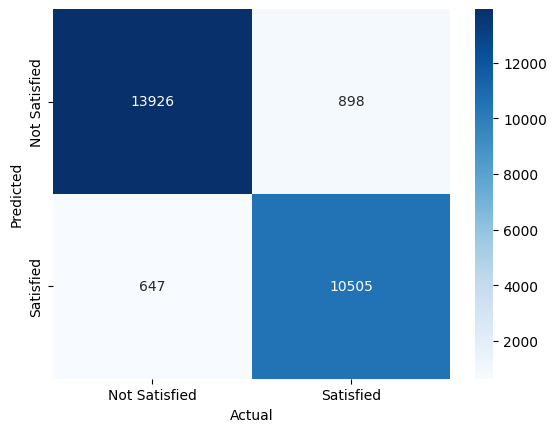

In [33]:
sns.heatmap(cm,annot=True,cmap='Blues',fmt='d',xticklabels=['Not Satisfied','Satisfied'],yticklabels=['Not Satisfied','Satisfied'])
plt.xlabel("Actual")
plt.ylabel("Predicted")

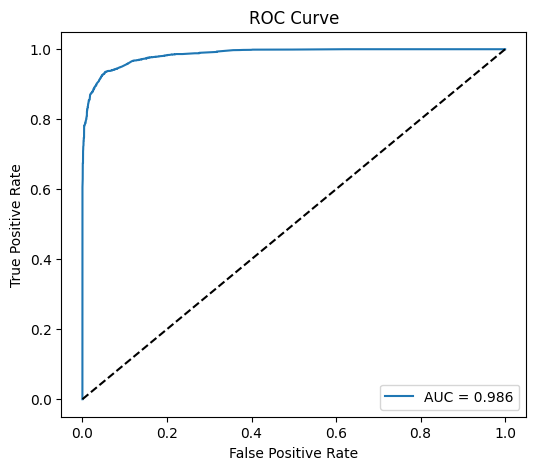

In [34]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_score = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_score:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Use Cross Validation (K-Fold)

In [35]:
from sklearn.model_selection import cross_val_score,KFold
kf=KFold(n_splits=5,shuffle=True)
score=cross_val_score(model,X_test,y_test,cv=kf)

In [36]:
score

array([0.93976135, 0.9387873 , 0.94456208, 0.93358999, 0.94071222])

In [37]:
print(f"K-Fold Mean Accuracy:{np.mean(score):.2f}")

K-Fold Mean Accuracy:0.94


### MLFlow for Experiment Tracking

In [38]:
import mlflow

TRACKING_URI = "sqlite:////Users/anirudhiyer/Desktop/AWS Full Pipeline/mlflow.db"
ARTIFACT_LOCATION = "file:///Users/anirudhiyer/Desktop/AWS Full Pipeline/mlartifacts"

mlflow.set_tracking_uri(TRACKING_URI)
print("Tracking URI:", mlflow.get_tracking_uri())  

Tracking URI: sqlite:////Users/anirudhiyer/Desktop/AWS Full Pipeline/mlflow.db


In [39]:
experiment_name = "Mlflow"

if mlflow.get_experiment_by_name(experiment_name) is None:
    mlflow.create_experiment(experiment_name, artifact_location=ARTIFACT_LOCATION)

mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='file:///Users/anirudhiyer/Desktop/AWS Full Pipeline/mlartifacts', creation_time=1782995351573, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782995351573, lifecycle_stage='active', name='Mlflow', tags={}, trace_location=None, workspace='default'>

In [40]:
from sklearn.metrics import roc_auc_score
with mlflow.start_run(run_name="XGBoost Base"):
    model = xgb.XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.01)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    mlflow.log_params({"n_estimators": 150, "max_depth": 6, "learning_rate": 0.01})
    mlflow.log_metrics({
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    })

    mlflow.xgboost.log_model(model, name="xgboost_base")

print("Finished. Tracking URI used:", mlflow.get_tracking_uri())

Finished. Tracking URI used: sqlite:////Users/anirudhiyer/Desktop/AWS Full Pipeline/mlflow.db


### LGBM Classifier

In [41]:
pip install lightgbm

You should consider upgrading via the '/Users/anirudhiyer/Desktop/AWS Full Pipeline/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [42]:
import lightgbm as lgb
lgbm=lgb.LGBMClassifier(n_estimators=250,max_depth=6,learning_rate=0.1,num_leaves=35)


In [43]:
lgbm.fit(X_train,y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 45025, number of negative: 58879
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001970 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 934
[LightGBM] [Info] Number of data points in the train set: 103904, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.433333 -> initscore=-0.268267
[LightGBM] [Info] Start training from score -0.268267
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

,boosting_type,'gbdt'
,num_leaves,35
,max_depth,6
,learning_rate,0.1
,n_estimators,250
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [44]:
y_pred=lgbm.predict(X_test)
acc=accuracy_score(y_test,y_pred)
pre=precision_score(y_pred,y_test)
rec=recall_score(y_pred,y_test)
f1=f1_score(y_pred,y_test)


In [45]:
print(f"Accuracy:{acc:.2f}")
print(f"Precision:{pre:.2f}")
print(f"Recall:{rec:.2f}")
print(f"F1 score:{f1:.2f}")

Accuracy:0.96
Precision:0.94
Recall:0.97
F1 score:0.96


<Axes: >

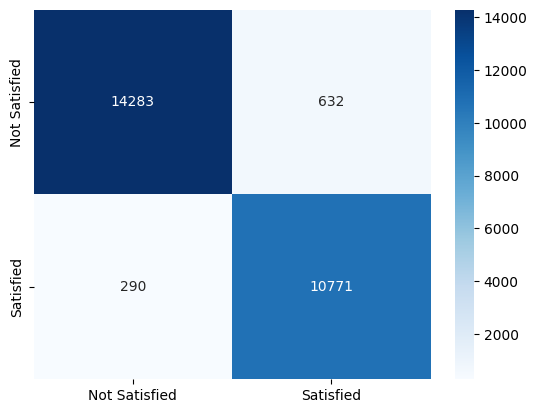

In [46]:
cm=confusion_matrix(y_pred,y_test)
sns.heatmap(cm,annot=True,cmap='Blues',fmt='d',xticklabels=['Not Satisfied','Satisfied'],yticklabels=['Not Satisfied','Satisfied'])

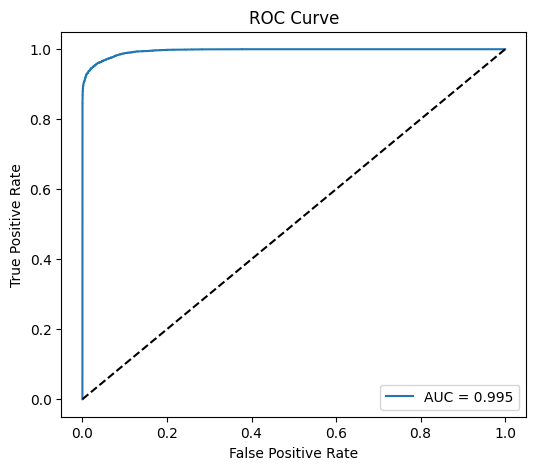

In [47]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_probs = lgbm.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_score = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_score:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [48]:
kf=KFold(n_splits=5,shuffle=True)
score=cross_val_score(lgbm,X_test,y_test,cv=kf)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9106, number of negative: 11674
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000606 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 931
[LightGBM] [Info] Number of data points in the train set: 20780, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.438210 -> initscore=-0.248431
[LightGBM] [Info] Start training from score -0.248431
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [49]:
score

array([0.95804465, 0.96034649, 0.95495669, 0.96207892, 0.95707411])

In [50]:
print(f"K-Fold Mean Accuracy:{np.mean(score):.2f}")

K-Fold Mean Accuracy:0.96


In [51]:
import mlflow.lightgbm

### Save LGBM Base onto MLFlow

In [52]:
import mlflow
import lightgbm as lgb

model = lgb.LGBMClassifier(n_estimators=250, max_depth=6, learning_rate=0.1, num_leaves=35)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

with mlflow.start_run(run_name="LightGBM Base"):
    mlflow.log_params({"n_estimators": 250, "max_depth": 6, "learning_rate": 0.1, "num_leaves": 35})
    mlflow.log_metrics({
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    })

    mlflow.lightgbm.log_model(
        model,
        name="lightgbm_base",
        skops_trusted_types=["lightgbm.sklearn.LGBMClassifier", "lightgbm.basic.Booster"],
    )

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 45025, number of negative: 58879
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001348 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 934
[LightGBM] [Info] Number of data points in the train set: 103904, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.433333 -> initscore=-0.268267
[LightGBM] [Info] Start training from score -0.268267
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

### SMOTE-TOMEK To handle imbalance in data

<Axes: xlabel='satisfaction', ylabel='count'>

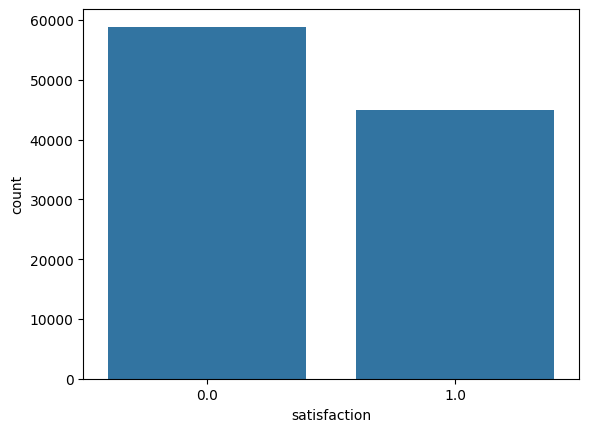

In [53]:
sns.countplot(x='satisfaction',data=df_train)

In [54]:
from imblearn.combine import SMOTETomek
tomek=SMOTETomek(random_state=42)
X_train_resampled,y_train_resampled=tomek.fit_resample(X_train,y_train)

In [55]:
X_train_resampled.shape

(109728, 22)

In [56]:
y_train_resampled.shape

(109728,)

In [57]:
lgbm=lgb.LGBMClassifier(n_estimators=250,max_depth=6,learning_rate=0.1,num_leaves=35)

In [58]:
lgbm.fit(X_train_resampled,y_train_resampled)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 54864, number of negative: 54864
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002675 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1945
[LightGBM] [Info] Number of data points in the train set: 109728, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

,boosting_type,'gbdt'
,num_leaves,35
,max_depth,6
,learning_rate,0.1
,n_estimators,250
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [59]:
y_pred=lgbm.predict(X_test)
acc=accuracy_score(y_test,y_pred)
pre=precision_score(y_pred,y_test)
rec=recall_score(y_pred,y_test)
f1=f1_score(y_pred,y_test)


In [60]:
print(f"Accuracy:{acc:.2f}")
print(f"Precision:{pre:.2f}")
print(f"Recall:{rec:.2f}")
print(f"F1 score:{f1:.2f}")

Accuracy:0.96
Precision:0.95
Recall:0.97
F1 score:0.96


<Axes: >

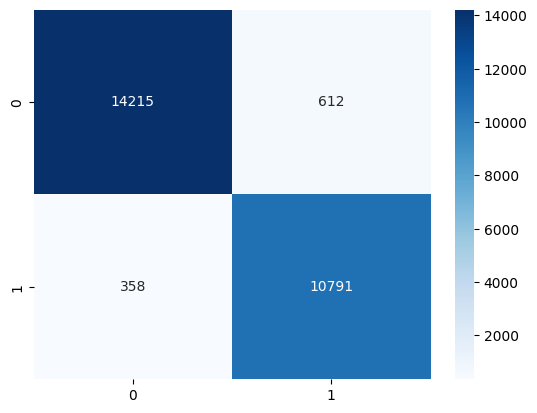

In [61]:
cm=confusion_matrix(y_pred,y_test)
sns.heatmap(cm,annot=True,cmap='Blues',fmt='d')

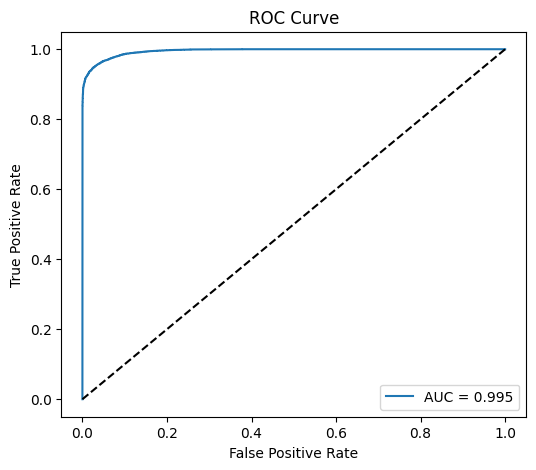

In [62]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_probs = lgbm.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_score = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_score:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [63]:
kf=KFold(n_splits=5,shuffle=True)
score=cross_val_score(lgbm,X_test,y_test,cv=kf)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9138, number of negative: 11642
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000491 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 931
[LightGBM] [Info] Number of data points in the train set: 20780, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.439750 -> initscore=-0.242178
[LightGBM] [Info] Start training from score -0.242178
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [64]:
score

array([0.96073903, 0.96150144, 0.96034649, 0.95611165, 0.95591915])

In [65]:
np.mean(score)

np.float64(0.9589235519141474)

In [66]:
import mlflow
import lightgbm as lgb

model = lgb.LGBMClassifier(n_estimators=250, max_depth=6, learning_rate=0.1, num_leaves=35)
model.fit(X_train_resampled, y_train_resampled)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

with mlflow.start_run(run_name="LightGBM V2"):
    mlflow.log_params({"n_estimators": 250, "max_depth": 6, "learning_rate": 0.1, "num_leaves": 35})
    mlflow.log_metrics({
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    })

    mlflow.lightgbm.log_model(
        model,
        name="lightgbm_v2",
        skops_trusted_types=["lightgbm.sklearn.LGBMClassifier", "lightgbm.basic.Booster"],
    )

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 54864, number of negative: 54864
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002230 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1945
[LightGBM] [Info] Number of data points in the train set: 109728, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi

In [67]:
model

,boosting_type,'gbdt'
,num_leaves,35
,max_depth,6
,learning_rate,0.1
,n_estimators,250
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [68]:
mlflow.lightgbm.log_model(
    model,
    name="lightgbm_champion"
)

In [76]:
import joblib 
joblib.dump(model,'lightgbm_v1.joblib')

['lightgbm_v1.joblib']

In [69]:
bucket

'customer-satisfaction-with-deploy'

In [ ]:
# df_test.to_csv('test_final.csv')

In [ ]:
# import boto3
# s3=boto3.client("s3")
# bucket="customer-satisfaction-with-deploy"
# s3.upload_file('test_final.csv',bucket,"data/test_final.csv")
